# HW14: эмбеддинги, FAISS, оценка retrieval, обновление базы и mini-RAG
В этом ноутбуке реализован полный обязательный pipeline на базе знаний по документации SQLite.

## 1. Импорты, seed и среда

In [1]:
import random
import re
from dataclasses import dataclass
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"SEED = {SEED}")
print(f"FAISS version: {faiss.__version__}")

SEED = 42
FAISS version: 1.13.2


## 2. База знаний и первичный анализ

In [2]:
BASE_DIR = Path('.')
RAW_DIR = BASE_DIR / 'data' / 'raw'
UPDATE_DIR = BASE_DIR / 'data' / 'update'
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


def load_documents(folder: Path) -> list[dict]:
    docs = []
    for path in sorted(folder.glob('*.txt')):
        raw = path.read_text(encoding='utf-8')
        lines = raw.splitlines()
        title = lines[0].replace('TITLE:', '').strip() if lines and lines[0].startswith('TITLE:') else ''
        source_url = lines[1].replace('SOURCE:', '').strip() if len(lines) > 1 and lines[1].startswith('SOURCE:') else ''
        docs.append(
            {
                'doc_id': path.name,
                'title': title,
                'source_url': source_url,
                'text': raw,
            }
        )
    return docs


raw_docs = load_documents(RAW_DIR)
update_docs = load_documents(UPDATE_DIR)

print(f"Число документов в основной базе: {len(raw_docs)}")
print(f"Число документов для обновления: {len(update_docs)}")

sample_df = pd.DataFrame(raw_docs)[['doc_id', 'title', 'source_url']].head(5)
sample_df

Число документов в основной базе: 10
Число документов для обновления: 3


,doc_id,title,source_url
0,sqlite_001_sql_syntax.txt,SQL As Understood By SQLite,https://sqlite.org/lang.html
1,sqlite_002_pragma.txt,PRAGMA Statements,https://sqlite.org/pragma.html
2,sqlite_003_core_functions.txt,Built-In Scalar SQL Functions,https://sqlite.org/lang_corefunc.html
3,sqlite_004_aggregate_functions.txt,Built-In Aggregate Functions,https://sqlite.org/lang_aggfunc.html
4,sqlite_005_date_time_functions.txt,Date And Time Functions,https://sqlite.org/lang_datefunc.html


In [3]:
for doc in raw_docs[:3]:
    print(f"\n=== {doc['doc_id']} | {doc['title']} ===")
    print(doc['text'][:350].replace('\n', ' '), '...')


=== sqlite_001_sql_syntax.txt | SQL As Understood By SQLite ===
TITLE: SQL As Understood By SQLite SOURCE: https://sqlite.org/lang.html  SQLite supports most of standard SQL, but it is not a clone of every other SQL engine. The language reference is organized around statements, functions, clauses, expressions, and syntax diagrams. For homework purposes, this page is useful as a map of the whole SQL surface area ...

=== sqlite_002_pragma.txt | PRAGMA Statements ===
TITLE: PRAGMA Statements SOURCE: https://sqlite.org/pragma.html  PRAGMA is a SQLite-specific extension used either to change how the SQLite library behaves or to query internal information that is not stored as ordinary user tables. Pragmas are issued through the same interfaces used for normal SQL, but they behave differently enough that they dese ...

=== sqlite_003_core_functions.txt | Built-In Scalar SQL Functions ===
TITLE: Built-In Scalar SQL Functions SOURCE: https://sqlite.org/lang_corefunc.html  SQLite provides a s

## 3. Чанкинг документов

In [4]:
def split_into_chunks(text: str, chunk_size: int = 520, overlap: int = 80) -> list[str]:
    clean = re.sub(r'\s+', ' ', text).strip()
    if not clean:
        return []

    step = max(1, chunk_size - overlap)
    chunks = []
    start = 0

    while start < len(clean):
        end = min(len(clean), start + chunk_size)
        piece = clean[start:end]

        if end < len(clean):
            last_space = piece.rfind(' ')
            if last_space > int(chunk_size * 0.6):
                end = start + last_space
                piece = clean[start:end]

        piece = piece.strip()
        if piece:
            chunks.append(piece)

        if end >= len(clean):
            break

        next_start = max(start + step, end - overlap)
        if next_start <= start:
            next_start = end
        start = next_start

    return chunks


def build_chunks(documents: list[dict], chunk_size: int, overlap: int) -> pd.DataFrame:
    records = []
    for doc in documents:
        doc_chunks = split_into_chunks(doc['text'], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk_text in enumerate(doc_chunks):
            records.append(
                {
                    'chunk_id': f"{doc['doc_id']}::chunk_{idx:03d}",
                    'doc_id': doc['doc_id'],
                    'title': doc['title'],
                    'chunk_text': chunk_text,
                }
            )
    return pd.DataFrame(records)


CHUNK_SIZE = 520
OVERLAP = 80
chunks_df = build_chunks(raw_docs, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Параметры чанкинга: chunk_size={CHUNK_SIZE}, overlap={OVERLAP}")
print(f"Число чанков (до обновления): {len(chunks_df)}")
chunks_df.head(3)

Параметры чанкинга: chunk_size=520, overlap=80
Число чанков (до обновления): 47


,chunk_id,doc_id,title,chunk_text
0,sqlite_001_sql_syntax.txt::chunk_000,sqlite_001_sql_syntax.txt,SQL As Understood By SQLite,TITLE: SQL As Understood By SQLite SOURCE: htt...
1,sqlite_001_sql_syntax.txt::chunk_001,sqlite_001_sql_syntax.txt,SQL As Understood By SQLite,"UPDATE, DELETE, CREATE TABLE, CREATE INDEX, DR..."
2,sqlite_001_sql_syntax.txt::chunk_002,sqlite_001_sql_syntax.txt,SQL As Understood By SQLite,real usage that means one script can create ta...


In [5]:
selected_doc = raw_docs[0]
selected_chunks = split_into_chunks(selected_doc['text'], chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Документ: {selected_doc['doc_id']}")
print(f"Получено чанков: {len(selected_chunks)}")
for i, chunk in enumerate(selected_chunks[:3], start=1):
    print(f"\nЧанк {i}:\n{chunk[:320]}...")

Документ: sqlite_001_sql_syntax.txt
Получено чанков: 5

Чанк 1:
TITLE: SQL As Understood By SQLite SOURCE: https://sqlite.org/lang.html SQLite supports most of standard SQL, but it is not a clone of every other SQL engine. The language reference is organized around statements, functions, clauses, expressions, and syntax diagrams. For homework purposes, this page is useful as a map ...

Чанк 2:
UPDATE, DELETE, CREATE TABLE, CREATE INDEX, DROP TABLE, ATTACH DATABASE, transaction control statements, RETURNING, UPSERT, PRAGMA, expressions, aggregate functions, core functions, date and time functions, window functions, and the WITH clause. A practical implication is that SQLite queries can mix familiar SQL with S...

Чанк 3:
real usage that means one script can create tables, load data, run queries, and adjust configuration in one pass. The parser also supports syntax diagrams that describe exactly which clauses may appear and in what order. For a retrieval system, this page is a high-level

## 4. Векторизация и индекс FAISS

In [6]:
@dataclass
class RetrievalBundle:
    chunks: pd.DataFrame
    vectorizer: TfidfVectorizer
    index: faiss.Index


def build_retrieval_bundle(chunks: pd.DataFrame) -> RetrievalBundle:
    vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(chunks['chunk_text'].tolist())
    embeddings = matrix.toarray().astype(np.float32)
    faiss.normalize_L2(embeddings)

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    return RetrievalBundle(chunks=chunks.reset_index(drop=True), vectorizer=vectorizer, index=index)


def retrieve(query: str, bundle: RetrievalBundle, top_k: int = 3, overfetch: int = 20) -> list[dict]:
    q = bundle.vectorizer.transform([query]).toarray().astype(np.float32)
    faiss.normalize_L2(q)

    fetch_k = min(max(top_k * 3, overfetch), len(bundle.chunks))
    scores, indices = bundle.index.search(q, fetch_k)

    hits = []
    seen_chunk = set()
    for rank_idx, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        row = bundle.chunks.iloc[int(idx)]
        if row['chunk_id'] in seen_chunk:
            continue
        seen_chunk.add(row['chunk_id'])
        hits.append(
            {
                'rank': rank_idx,
                'score': float(score),
                'doc_id': row['doc_id'],
                'chunk_id': row['chunk_id'],
                'chunk_text': row['chunk_text'],
            }
        )
        if len(hits) >= top_k:
            break
    return hits


base_bundle = build_retrieval_bundle(chunks_df)
print(f"Построен индекс FAISS: {base_bundle.index.ntotal} векторов")

Построен индекс FAISS: 47 векторов


In [7]:
example_queries = [
    'What is PRAGMA in SQLite?',
    'How does dynamic typing work in SQLite?',
    'What are generated columns?',
    'Which date and time functions exist?',
    'What are row values?'
]

for q in example_queries:
    hits = retrieve(q, base_bundle, top_k=3)
    print(f"\nЗАПРОС: {q}")
    for h in hits:
        print(f"  rank={h['rank']} score={h['score']:.4f} источник={h['doc_id']}")


ЗАПРОС: What is PRAGMA in SQLite?
  rank=1 score=0.2828 источник=sqlite_002_pragma.txt
  rank=2 score=0.2717 источник=sqlite_002_pragma.txt
  rank=3 score=0.1329 источник=sqlite_002_pragma.txt

ЗАПРОС: How does dynamic typing work in SQLite?
  rank=1 score=0.2178 источник=sqlite_006_datatypes.txt
  rank=2 score=0.0987 источник=sqlite_010_expressions.txt
  rank=3 score=0.0778 источник=sqlite_006_datatypes.txt

ЗАПРОС: What are generated columns?
  rank=1 score=0.5640 источник=sqlite_008_generated_columns.txt
  rank=2 score=0.5398 источник=sqlite_008_generated_columns.txt
  rank=3 score=0.2908 источник=sqlite_008_generated_columns.txt

ЗАПРОС: Which date and time functions exist?
  rank=1 score=0.4803 источник=sqlite_005_date_time_functions.txt
  rank=2 score=0.2842 источник=sqlite_005_date_time_functions.txt
  rank=3 score=0.1647 источник=sqlite_001_sql_syntax.txt

ЗАПРОС: What are row values?
  rank=1 score=0.4437 источник=sqlite_007_row_values.txt
  rank=2 score=0.2707 источник=sqlit

## 5. Контрольные запросы и оценка retrieval

In [8]:
def unique_in_order(items):
    out = []
    for x in items:
        if x not in out:
            out.append(x)
    return out


def evaluate_retrieval(queries: list[dict], bundle: RetrievalBundle, top_k: int = 3):
    rows = []
    for item in queries:
        expected_sources = item['expected_sources']
        hits = retrieve(item['query'], bundle, top_k=top_k)
        retrieved_sources = unique_in_order([h['doc_id'] for h in hits])

        intersection = set(retrieved_sources) & set(expected_sources)
        hit_at_k = int(bool(intersection))
        recall_at_k = len(intersection) / len(set(expected_sources))

        rank_of_first = None
        for i, source in enumerate(retrieved_sources, start=1):
            if source in expected_sources:
                rank_of_first = i
                break

        rows.append(
            {
                'query': item['query'],
                'expected_source': ' | '.join(expected_sources),
                'retrieved_sources': ' | '.join(retrieved_sources),
                'hit_at_k': hit_at_k,
                'recall_at_k': round(float(recall_at_k), 4),
                'rank_of_first_relevant': rank_of_first,
            }
        )

    eval_df = pd.DataFrame(rows)
    metrics = {
        'top_k': top_k,
        'hit_at_k': float(eval_df['hit_at_k'].mean()),
        'recall_at_k': float(eval_df['recall_at_k'].mean()),
        'num_queries': int(len(eval_df)),
    }
    return eval_df, metrics


control_queries = [
    {'query': 'What is PRAGMA in SQLite and why can unknown pragmas be risky?', 'expected_sources': ['sqlite_002_pragma.txt']},
    {'query': 'What is the difference between count(*) and count(X)?', 'expected_sources': ['sqlite_004_aggregate_functions.txt']},
    {'query': 'Which date and time functions are documented by SQLite?', 'expected_sources': ['sqlite_005_date_time_functions.txt']},
    {'query': 'How does dynamic typing and type affinity work in SQLite?', 'expected_sources': ['sqlite_006_datatypes.txt']},
    {'query': 'Which built-in functions help with lower upper trim and substr?', 'expected_sources': ['sqlite_003_core_functions.txt']},
    {'query': 'What are generated columns and VIRTUAL vs STORED modes?', 'expected_sources': ['sqlite_008_generated_columns.txt']},
    {'query': 'Why would someone choose STRICT tables?', 'expected_sources': ['sqlite_009_strict_tables.txt']},
    {'query': 'What placeholder parameter styles are supported in SQLite expressions?', 'expected_sources': ['sqlite_010_expressions.txt']},
    {'query': 'What are row values and tuple comparisons in SQLite?', 'expected_sources': ['sqlite_007_row_values.txt']},
    {'query': 'How are BOOLEAN-like values represented in SQLite?', 'expected_sources': ['sqlite_006_datatypes.txt']},
]

TOP_K = 3
retrieval_eval_df, retrieval_metrics = evaluate_retrieval(control_queries, base_bundle, top_k=TOP_K)

retrieval_eval_path = ARTIFACTS_DIR / 'retrieval_eval.csv'
retrieval_eval_df.to_csv(retrieval_eval_path, index=False, encoding='utf-8')

print('Метрики retrieval:', retrieval_metrics)
retrieval_eval_df

Метрики retrieval: {'top_k': 3, 'hit_at_k': 1.0, 'recall_at_k': 1.0, 'num_queries': 10}


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,What is PRAGMA in SQLite and why can unknown p...,sqlite_002_pragma.txt,sqlite_002_pragma.txt,1,1.0,1
1,What is the difference between count(*) and co...,sqlite_004_aggregate_functions.txt,sqlite_004_aggregate_functions.txt,1,1.0,1
2,Which date and time functions are documented b...,sqlite_005_date_time_functions.txt,sqlite_005_date_time_functions.txt | sqlite_00...,1,1.0,1
3,How does dynamic typing and type affinity work...,sqlite_006_datatypes.txt,sqlite_006_datatypes.txt | sqlite_009_strict_t...,1,1.0,1
4,Which built-in functions help with lower upper...,sqlite_003_core_functions.txt,sqlite_003_core_functions.txt,1,1.0,1
5,What are generated columns and VIRTUAL vs STOR...,sqlite_008_generated_columns.txt,sqlite_008_generated_columns.txt,1,1.0,1
6,Why would someone choose STRICT tables?,sqlite_009_strict_tables.txt,sqlite_009_strict_tables.txt,1,1.0,1
7,What placeholder parameter styles are supporte...,sqlite_010_expressions.txt,sqlite_010_expressions.txt | sqlite_001_sql_sy...,1,1.0,1
8,What are row values and tuple comparisons in S...,sqlite_007_row_values.txt,sqlite_007_row_values.txt,1,1.0,1
9,How are BOOLEAN-like values represented in SQL...,sqlite_006_datatypes.txt,sqlite_005_date_time_functions.txt | sqlite_00...,1,1.0,3


## 6. Небольшой эксперимент по параметрам retrieval

In [9]:
experiment_rows = []
for candidate_top_k in [1, 3]:
    _, metrics = evaluate_retrieval(control_queries, base_bundle, top_k=candidate_top_k)
    experiment_rows.append(
        {
            'top_k': candidate_top_k,
            'hit_at_k': metrics['hit_at_k'],
            'recall_at_k': metrics['recall_at_k'],
        }
    )

experiment_df = pd.DataFrame(experiment_rows).sort_values('top_k')
experiment_df

,top_k,hit_at_k,recall_at_k
0,1,0.9,0.9
1,3,1.0,1.0


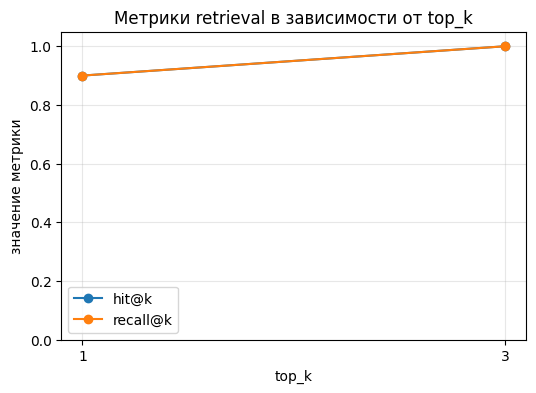

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(experiment_df['top_k'], experiment_df['hit_at_k'], marker='o', label='hit@k')
plt.plot(experiment_df['top_k'], experiment_df['recall_at_k'], marker='o', label='recall@k')
plt.xticks(experiment_df['top_k'])
plt.ylim(0.0, 1.05)
plt.xlabel('top_k')
plt.ylabel('значение метрики')
plt.title('Метрики retrieval в зависимости от top_k')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 7. Обновление базы знаний и переиндексация

In [11]:
updated_docs = raw_docs + update_docs
updated_chunks_df = build_chunks(updated_docs, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
updated_bundle = build_retrieval_bundle(updated_chunks_df)

print(f"Документов после обновления: {len(updated_docs)}")
print(f"Чанков после обновления: {len(updated_chunks_df)}")

Документов после обновления: 13


Чанков после обновления: 59


In [12]:
before_after_queries = [
    'How do window functions differ from aggregates?',
    'How can I get row numbers using row_number in SQLite?',
    'What is FTS5 and why would I use MATCH?',
    'How do tokenizers influence FTS5 search quality?',
    'What does WITH do and how are recursive CTEs different?',
    'What does PRAGMA do and can I query pragma metadata via SELECT?',
]

before_after_rows = []
for query in before_after_queries:
    before_sources = unique_in_order([h['doc_id'] for h in retrieve(query, base_bundle, top_k=TOP_K)])
    after_sources = unique_in_order([h['doc_id'] for h in retrieve(query, updated_bundle, top_k=TOP_K)])

    before_after_rows.append(
        {
            'query': query,
            'before_retrieved_sources': ' | '.join(before_sources),
            'after_retrieved_sources': ' | '.join(after_sources),
            'changed': str(before_sources != after_sources),
        }
    )

before_after_df = pd.DataFrame(before_after_rows)
before_after_path = ARTIFACTS_DIR / 'retrieval_before_after_update.csv'
before_after_df.to_csv(before_after_path, index=False, encoding='utf-8')

before_after_df

,query,before_retrieved_sources,after_retrieved_sources,changed
0,How do window functions differ from aggregates?,sqlite_001_sql_syntax.txt | sqlite_004_aggrega...,sqlite_011_window_functions.txt,True
1,How can I get row numbers using row_number in ...,sqlite_007_row_values.txt,sqlite_011_window_functions.txt | sqlite_007_r...,True
2,What is FTS5 and why would I use MATCH?,sqlite_009_strict_tables.txt | sqlite_005_date...,sqlite_012_fts5.txt,True
3,How do tokenizers influence FTS5 search quality?,sqlite_004_aggregate_functions.txt,sqlite_012_fts5.txt,True
4,What does WITH do and how are recursive CTEs d...,sqlite_006_datatypes.txt | sqlite_003_core_fun...,sqlite_013_with_clause.txt,True
5,What does PRAGMA do and can I query pragma met...,sqlite_002_pragma.txt,sqlite_002_pragma.txt,False


## 8. Mini-RAG

In [13]:
def simple_rag_answer(question: str, hits: list[dict]):
    context = ' '.join(hit['chunk_text'] for hit in hits)
    sentences = re.split(r'(?<=[.!?])\s+', context)

    query_terms = set(re.findall(r'[a-zA-Z0-9_]+', question.lower()))
    scored = []
    for sentence in sentences:
        sent = sentence.strip()
        if not sent:
            continue
        sent_terms = set(re.findall(r'[a-zA-Z0-9_]+', sent.lower()))
        overlap = len(query_terms & sent_terms)
        scored.append((overlap, sent))

    scored.sort(key=lambda x: x[0], reverse=True)
    best = [s for _, s in scored[:2]]
    answer = ' '.join(best) if best else 'Not enough relevant context in the knowledge base.'

    sources = unique_in_order([hit['doc_id'] for hit in hits])
    return answer, sources


rag_questions = [
    'How do window functions differ from ordinary aggregates?',
    'When should I use FTS5 instead of LIKE?',
    'Does WITH create a permanent table?',
    'How can I get previous-row values in SQLite analytics queries?',
    'How are BOOLEAN-like values stored in SQLite?',
]

rag_rows = []
for question in rag_questions:
    hits = retrieve(question, updated_bundle, top_k=TOP_K)
    answer, sources = simple_rag_answer(question, hits)
    rag_rows.append(
        {
            'question': question,
            'answer': answer,
            'retrieved_sources': ' | '.join(sources),
        }
    )

rag_df = pd.DataFrame(rag_rows)
rag_examples_path = ARTIFACTS_DIR / 'rag_examples.csv'
rag_df.to_csv(rag_examples_path, index=False, encoding='utf-8')

rag_df

,question,answer,retrieved_sources
0,How do window functions differ from ordinary a...,Example question themes: - How do window funct...,sqlite_011_window_functions.txt
1,When should I use FTS5 instead of LIKE?,- Why would someone use FTS5 instead of LIKE? ...,sqlite_012_fts5.txt
2,Does WITH create a permanent table?,- Does WITH create a permanent table? The key ...,sqlite_013_with_clause.txt | sqlite_001_sql_sy...
3,How can I get previous-row values in SQLite an...,- How can I get the previous row with lag? In ...,sqlite_007_row_values.txt | sqlite_011_window_...
4,How are BOOLEAN-like values stored in SQLite?,"A declaration such as VARCHAR, BOOLEAN, or DEC...",sqlite_006_datatypes.txt | sqlite_008_generate...


## 9. Краткий анализ ошибок (3-5 примеров mini-RAG)

In [14]:
analysis_questions = [
    'How do window functions differ from ordinary aggregates?',
    'Does WITH create a permanent table?',
    'How can I get previous-row values in SQLite analytics queries?',
    'How are BOOLEAN-like values stored in SQLite?',
]

for q in analysis_questions:
    hits = retrieve(q, updated_bundle, top_k=TOP_K)
    answer, sources = simple_rag_answer(q, hits)
    print(f"\nВопрос: {q}")
    print(f"Источники: {sources}")
    print(f"Ответ: {answer[:350]}...")


Вопрос: How do window functions differ from ordinary aggregates?


Источники: ['sqlite_011_window_functions.txt']
Ответ: Example question themes: - How do window functions differ from aggregates? Unlike ordinary aggregates, they do not collapse the result into one row per group....

Вопрос: Does WITH create a permanent table?
Источники: ['sqlite_013_with_clause.txt', 'sqlite_001_sql_syntax.txt']
Ответ: - Does WITH create a permanent table? The key point for beginners is that WITH does not create a permanent table; it defines temporary query components that exist only for the UPDATE, DELETE, CREATE TABLE, CREATE INDEX, DROP TABLE, ATTACH DATABASE, transaction control statements, RETURNING, UPSERT, PRAGMA, expressions, aggregate functions, core fun...

Вопрос: How can I get previous-row values in SQLite analytics queries?
Источники: ['sqlite_007_row_values.txt', 'sqlite_011_window_functions.txt']
Ответ: - How can I get the previous row with lag? In SQLite, row values can appear in comparisons and in some multi-column operations....

Вопрос: How are BOO

### Комментарии по пограничным случаям
- Вопрос `previous-row values` может собирать смешанный контекст из row values и window functions, поэтому качество ответа зависит от порядка выдачи retrieval.
- Вопрос `BOOLEAN-like values` иногда смешивает материалы про datatypes и соседние темы, из-за чего в ответ попадают шумные фрагменты.
- Простой extractive-генератор хорошо воспроизводим, но слабее модели, которая умеет аккуратно синтезировать ответ по контексту.